In [1]:
pip install -Uq diffusers transformers fastcore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 51.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 99.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.2/112.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 33.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip uninstall torch torchvision torchaudio -y
!pip cache purge
!pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Files removed: 24
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 75.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 101.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.8 

In [4]:
import logging
from pathlib import Path
import matplotlib.pyplot as plt
from fastcore.all import concat
from PIL import Image
from diffusers import DiffusionPipeline
import torch
logging.disable(logging.WARNING)
torch.manual_seed(1)


Stable diffusion pipeline


In [5]:
pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", variant="fp16", torch_dtype=torch.float16).to('cuda')

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [6]:
!ls ~/.cache/huggingface/hub

CACHEDIR.TAG  models--stabilityai--stable-diffusion-xl-base-1.0


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


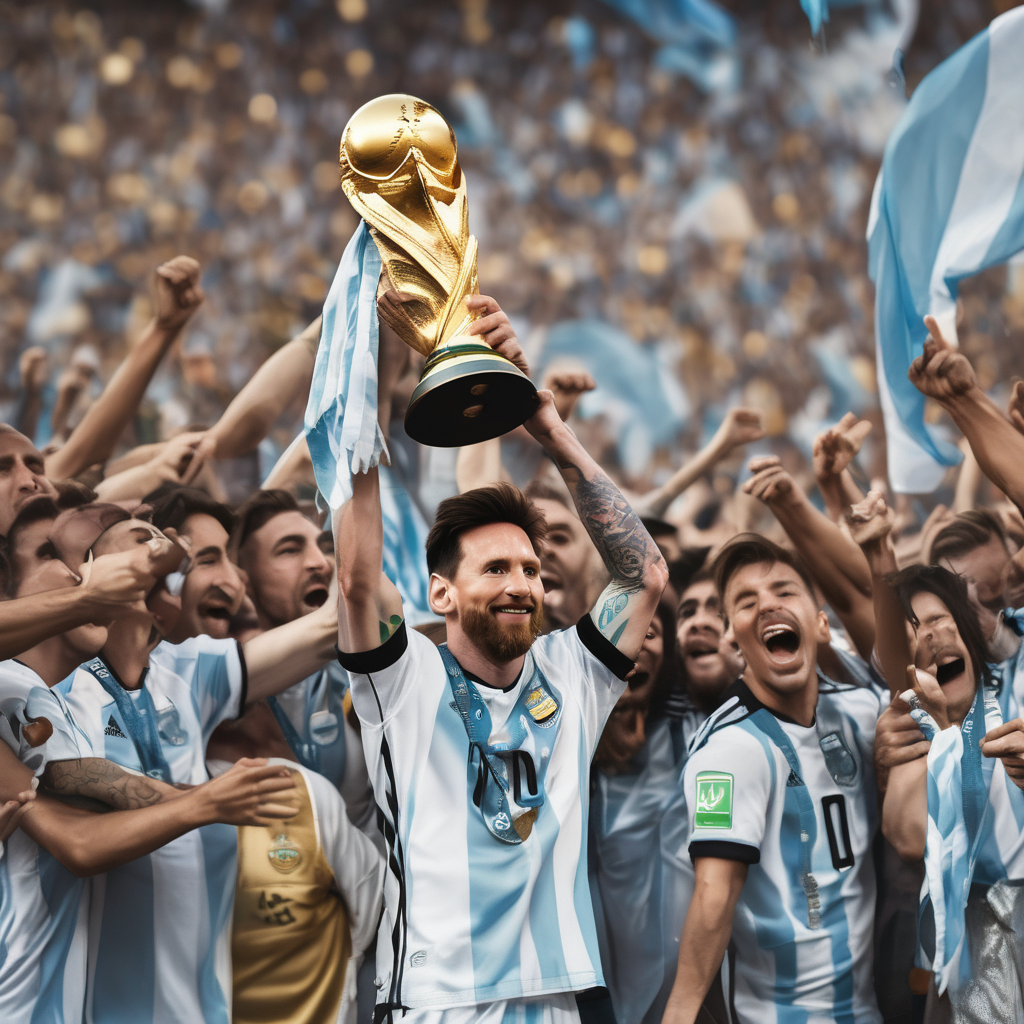

In [7]:
prompt = "A realistic sports photograph of Lionel Messi celebrating a World Cup victory, holding the golden trophy, Argentina jersey number 10, surrounded by teammates and fans, authentic football stadium atmosphere, captured by a professional sports photographer, Canon EOS R5, 400mm telephoto lens, natural lighting, realistic skin texture, sharp details, documentary photography style"
pipeline(prompt = prompt).images[0]

In [ ]:
torch.manual_seed(1024)
pipeline(prompt, num_inference_steps=3).images[0]  #showing the image after denoising step number 3

In [ ]:
torch.manual_seed(1024)
pipeline(prompt, num_inference_steps=100).images[0]

  0%|          | 0/100 [00:00<?, ?it/s]

Classifier-Free Guidance

In [ ]:
def image_grid(imgs, rows ,cols):
    w,h = imgs[0].size    #extraction of width and height of the image
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, img in enumerate(imgs):
        grid.paste(img,box=(i%cols*w, i//cols*h))
    return grid    


In [ ]:
num_rows , num_cols = 4,4
prompts = [prompt] * num_cols


In [ ]:
pipeline(prompt, guidance_scale=7.5).images[0]